# Proyecto 2 — Análisis Inicial y Selección de Problema

**Etapa:** Parte I — Búsqueda, EDA inicial y Selección de Problema  

---

##Datasets analizados

| # | Dataset | Fuente | Dominio | Problema |
|---|---------|--------|---------|----------|
| 1 | Bank Customer Churn | Kaggle | Banca / Finanzas | Clasificación |
| 2 | Heart Disease | Kaggle | Salud / Medicina | Clasificación |
| 3 | Video Game Sales + Metacritic | Kaggle | Entretenimiento | Regresión |
| 4 | Most Streamed Spotify Songs 2024 | Kaggle | Música / Streaming | Regresión |

---


# Diccionario de Columnas — Proyecto 2

---
##  Dataset 2 — Heart Disease
**Archivo:** `heart_disease.csv` | **Columnas:** 21

| # | Columna (original) | Traducción | Tipo | Descripción |
|---|---|---|---|---|
| 1 | Age | Edad | float | Edad del individuo |
| 2 | Gender | Género | str | Género del individuo (Male = Masculino / Female = Femenino) |
| 3 | Blood Pressure | Presión arterial | float | Presión arterial sistólica del individuo (mm Hg) |
| 4 | Cholesterol Level | Nivel de colesterol | float | Nivel total de colesterol en sangre del individuo (mg/dl) |
| 5 | Exercise Habits | Hábitos de ejercicio | str | Nivel de actividad física (Low = Bajo / Medium = Medio / High = Alto) |
| 6 | Smoking | Fumador | str | Indica si el individuo fuma (Yes = Sí / No = No) |
| 7 | Family Heart Disease | Antecedentes familiares | str | Historial familiar de enfermedad cardíaca (Yes = Sí / No = No) |
| 8 | Diabetes | Diabetes | str | Indica si el individuo tiene diabetes (Yes = Sí / No = No) |
| 9 | BMI | IMC (Índice de masa corporal) | float | Índice de masa corporal del individuo |
| 10 | High Blood Pressure | Hipertensión arterial | str | Indica si el individuo tiene presión arterial alta (Yes = Sí / No = No) |
| 11 | Low HDL Cholesterol | Colesterol HDL bajo | str | Indica si tiene colesterol HDL bajo — el "colesterol bueno" (Yes = Sí / No = No) |
| 12 | High LDL Cholesterol | Colesterol LDL alto | str | Indica si tiene colesterol LDL alto — el "colesterol malo" (Yes = Sí / No = No) |
| 13 | Alcohol Consumption | Consumo de alcohol | str | Nivel de consumo de alcohol (None = Ninguno / Low = Bajo / Medium = Medio / High = Alto) |
| 14 | Stress Level | Nivel de estrés | str | Nivel de estrés del individuo (Low = Bajo / Medium = Medio / High = Alto) |
| 15 | Sleep Hours | Horas de sueño | float | Número de horas que duerme el individuo por noche |
| 16 | Sugar Consumption | Consumo de azúcar | str | Nivel de consumo de azúcar (Low = Bajo / Medium = Medio / High = Alto) |
| 17 | Triglyceride Level | Nivel de triglicéridos | float | Nivel de triglicéridos en sangre del individuo |
| 18 | Fasting Blood Sugar | Glucemia en ayunas | float | Nivel de glucosa en sangre del individuo en estado de ayuno |
| 19 | CRP Level | Nivel de PCR | float | Nivel de proteína C-reactiva — marcador de inflamación en el organismo |
| 20 | Homocysteine Level | Nivel de homocisteína | float | Aminoácido cuyo nivel elevado afecta la salud de los vasos sanguíneos |
| 21 | **Heart Disease Status** | **Estado de enfermedad cardíaca** | str | **Variable objetivo: indica si el individuo tiene enfermedad cardíaca (Yes = Sí / No = No)** |

---

---
# Sección 0 — Configuración del entorno

Lo primero que debemos hacer es conectarnos al drive para poder acceder a los dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Librerías
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

In [ ]:
#  Función reutilizable: resumen de nulos
def resumen_nulos(df, titulo=''):
    null_df = pd.DataFrame({
        'Nulos': df.isnull().sum(),
        '% Nulos': (df.isnull().sum() / len(df) * 100).round(1)
    }).sort_values('% Nulos', ascending=False)
    null_df = null_df[null_df['Nulos'] > 0]
    if null_df.empty:
        print(f'{titulo}: Sin valores nulos.')
        return null_df
    print(f'\n Nulos en {titulo}:')
    print(null_df.to_string())
    return null_df

# Función reutilizable: outliers IQR
def resumen_outliers(df, cols, nombre=''):
    rows = []
    for col in cols:
        if col not in df.columns: continue
        data = df[col].dropna()
        Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
        IQR = Q3 - Q1
        n = ((data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)).sum()
        rows.append({
            'Variable': col, 'Q1': round(Q1, 2), 'Q3': round(Q3, 2),
            'IQR': round(IQR, 2), 'N Outliers': n,
            '% Outliers': round(n / len(data) * 100, 2)
        })
    result = pd.DataFrame(rows)
    if not result.empty:
        print(f'\n [{nombre}] Resumen de outliers (método IQR):')
        display(result)
    return result


---
#  Dataset 2 — Heart Disease
**Fuente:** Kaggle — `oktayrdeki/heart-disease`  
**Dominio:** Salud / Medicina  
**Problema:** Clasificación binaria — predecir presencia de enfermedad cardíaca

## 2.1 Descripción del conjunto de datos

Variables clínicas de pacientes para diagnóstico de enfermedad cardíaca.  
Sin valores nulos, rico en variables numéricas continuas con significado clínico real.

| Variable | Tipo | Descripción |
|----------|------|-------------|
| Age | float | Edad del individuo |
| Gender |  str | Género del individuo (Male = Masculino / Female = Femenino) |
| Blood Pressure |  float | Presión arterial sistólica del individuo (mm Hg) |
| Cholesterol Level |  float | Nivel total de colesterol en sangre del individuo (mg/dl) |
| Exercise Habits |  str | Nivel de actividad física (Low = Bajo / Medium = Medio / High = Alto) |
| Smoking |  str | Indica si el individuo fuma (Yes = Sí / No = No) |
|Family Heart Disease | str | Historial familiar de enfermedad cardíaca (Yes = Sí / No = No) |
|  Diabetes |  str | Indica si el individuo tiene diabetes (Yes = Sí / No = No) |
|BMI | float | Índice de masa corporal del individuo |
| High Blood Pressure | str | Indica si el individuo tiene presión arterial alta (Yes = Sí / No = No) |
| Low HDL Cholesterol | str | Indica si tiene colesterol HDL bajo — el "colesterol bueno" (Yes = Sí / No = No) |
| High LDL Cholesterol |  str | Indica si tiene colesterol LDL alto — el "colesterol malo" (Yes = Sí / No = No) |
|Alcohol Consumption |  str | Nivel de consumo de alcohol (None = Ninguno / Low = Bajo / Medium = Medio / High = Alto) |
|Stress Level | str | Nivel de estrés del individuo (Low = Bajo / Medium = Medio / High = Alto) |
|  Sleep Hours |  float | Número de horas que duerme el individuo por noche |
|  Sugar Consumption | str | Nivel de consumo de azúcar (Low = Bajo / Medium = Medio / High = Alto) |
| Triglyceride Level |  float | Nivel de triglicéridos en sangre del individuo |
|Fasting Blood Sugar |  float | Nivel de glucosa en sangre del individuo en estado de ayuno |
| CRP Level |  float | Nivel de proteína C-reactiva — marcador de inflamación en el organismo |
|  Homocysteine Level |  float | Aminoácido cuyo nivel elevado afecta la salud de los vasos sanguíneos |
|  **Heart Disease Status** |  str | **Variable objetivo: indica si el individuo tiene enfermedad cardíaca (Yes = Sí / No = No)** |

## 2.2 Descarga y carga de datos

In [ ]:
df_heart = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/heart_disease.csv')

# Estandarizar nombre del target
target_candidates = [c for c in df_heart.columns
                     if any(k in c.lower() for k in ['status', 'disease', 'target'])]
if target_candidates and target_candidates[-1] != 'Heart Disease Status':
    df_heart.rename(columns={target_candidates[-1]: 'Heart Disease Status'}, inplace=True)
    print(f'\nTarget renombrado a: Heart Disease Status')
else:
    print('\nNombre del target correcto: Heart Disease Status')

print(f'Dataset cargado: {df_heart.shape[0]:,} filas × {df_heart.shape[1]} columnas')
df_heart.head()


Nombre del target correcto: Heart Disease Status
Dataset cargado: 10,000 filas × 21 columnas


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


## 2.3 Análisis estadístico descriptivo

In [ ]:
print(f'Informacion del dataset: \n')
df_heart.info()

print(f'\nPrimeras 5 filas: \n\n {df_heart.head()}\n')
print(f'Últimas 5 filas: \n\n {df_heart.tail()}\n')
print(f'Cantidad de elementos duplicados:\n\n {df_heart.duplicated()}\n')
print(f'Cantidad de elementos nulos:\n \n{df_heart.isnull().sum()}\n')
print(f'Tipos de datos :\n \n {df_heart.dtypes.to_string()}')
num2 = df_heart.select_dtypes(include=np.number)
desc2 = num2.describe().T
desc2['skewness'] = num2.skew().round(3)
desc2['kurtosis'] = num2.kurtosis().round(3)
display(desc2.style.background_gradient(cmap='YlOrRd', subset=['skewness']))

pseudo_cat2 = ['sex','cp','fbs','restecg','exang','slope','ca','thal','target']
pseudo_cat2 = [c for c in pseudo_cat2 if c in df_heart.columns]
print('\n Distribución de variables categóricas (codificadas) ')
for col in pseudo_cat2:
    print(f'\n{col}: {dict(df_heart[col].value_counts().sort_index())}')

Informacion del dataset: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float6

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Age,9971.000000,49.296259,18.193970,18.000000,34.000000,49.000000,65.000000,80.000000,-0.007000,-1.204000
Blood Pressure,9981.000000,149.757740,17.572969,120.000000,134.000000,150.000000,165.000000,180.000000,0.014000,-1.212000
Cholesterol Level,9970.000000,225.425577,43.575809,150.000000,187.000000,226.000000,263.000000,300.000000,-0.007000,-1.205000
BMI,9978.000000,29.077269,6.307098,18.002837,23.658075,29.079492,34.520015,39.996954,-0.021000,-1.181000
Sleep Hours,9975.000000,6.991329,1.753195,4.000605,5.449866,7.003252,8.531577,9.999952,0.000000,-1.224000
Triglyceride Level,9974.000000,250.734409,87.067226,100.000000,176.000000,250.000000,326.000000,400.000000,0.006000,-1.199000
Fasting Blood Sugar,9978.000000,120.142213,23.584011,80.000000,99.000000,120.000000,141.000000,160.000000,-0.009000,-1.230000
CRP Level,9974.000000,7.472201,4.340248,0.003647,3.674126,7.472164,11.255592,14.997087,-0.004000,-1.209000
Homocysteine Level,9980.000000,12.456271,4.323426,5.000236,8.723334,12.409395,16.140564,19.999037,0.008000,-1.180000



 Distribución de variables categóricas (codificadas) 


## 2.4 Identificación de valores nulos y outliers

In [ ]:
nulos_heart = resumen_nulos(df_heart, 'df_heart')

if not nulos_heart.empty:
    print('\n Estrategia de tratamiento:')
    for col, row in nulos_heart.iterrows():
        if row['% Nulos'] > 50:
            print(f'  {col} ({row["% Nulos"]}%): considerar eliminar la columna')
        elif df_heart[col].dtype == 'object':
            print(f'  {col} ({row["% Nulos"]}%): imputar con moda')
            df_heart[col].fillna(df_heart[col].mode()[0], inplace=True)
        else:
            print(f'  {col} ({row["% Nulos"]}%): imputar con mediana')
            df_heart[col].fillna(df_heart[col].median(), inplace=True)
    print('\nNulos tratados.')
    resumen_nulos(df_heart, 'df_heart — tras tratamiento')


 Nulos en df_heart:
                      Nulos  % Nulos
Alcohol Consumption    2586     25.9
Cholesterol Level        30      0.3
High Blood Pressure      26      0.3
Diabetes                 30      0.3
Age                      29      0.3
Sugar Consumption        30      0.3
CRP Level                26      0.3
Triglyceride Level       26      0.3
High LDL Cholesterol     26      0.3
Exercise Habits          25      0.2
Blood Pressure           19      0.2
Gender                   19      0.2
BMI                      22      0.2
Low HDL Cholesterol      25      0.2
Smoking                  25      0.2
Family Heart Disease     21      0.2
Sleep Hours              25      0.2
Stress Level             22      0.2
Fasting Blood Sugar      22      0.2
Homocysteine Level       20      0.2

 Estrategia de tratamiento:
  Alcohol Consumption (25.9%): imputar con moda
  Cholesterol Level (0.3%): imputar con mediana
  High Blood Pressure (0.3%): imputar con moda
  Diabetes (0.3%): imputar con

El resultado del tratamiento de nulos viene por la funcion que cree mas arriba. Debo aclarar que al ser 4 dataset y por temas de tiempo lo hice asi mas "general" el tratado de nulos, cuando es un solo dataset se le puede brindar una limpieza mas profunda

In [ ]:
n_dup_heart = df_heart.duplicated().sum()
print(f'Filas duplicadas: {n_dup_heart}')

if n_dup_heart > 0:
    df_heart.drop_duplicates(inplace=True)
    df_heart.reset_index(drop=True, inplace=True)
    print(f' Duplicados eliminados. Shape actual: {df_heart.shape}')
else:
    print(' Sin filas duplicadas.')

Filas duplicadas: 0
 Sin filas duplicadas.


## 2.4 Visualizaciones
### 2.4.1 Distribución del target

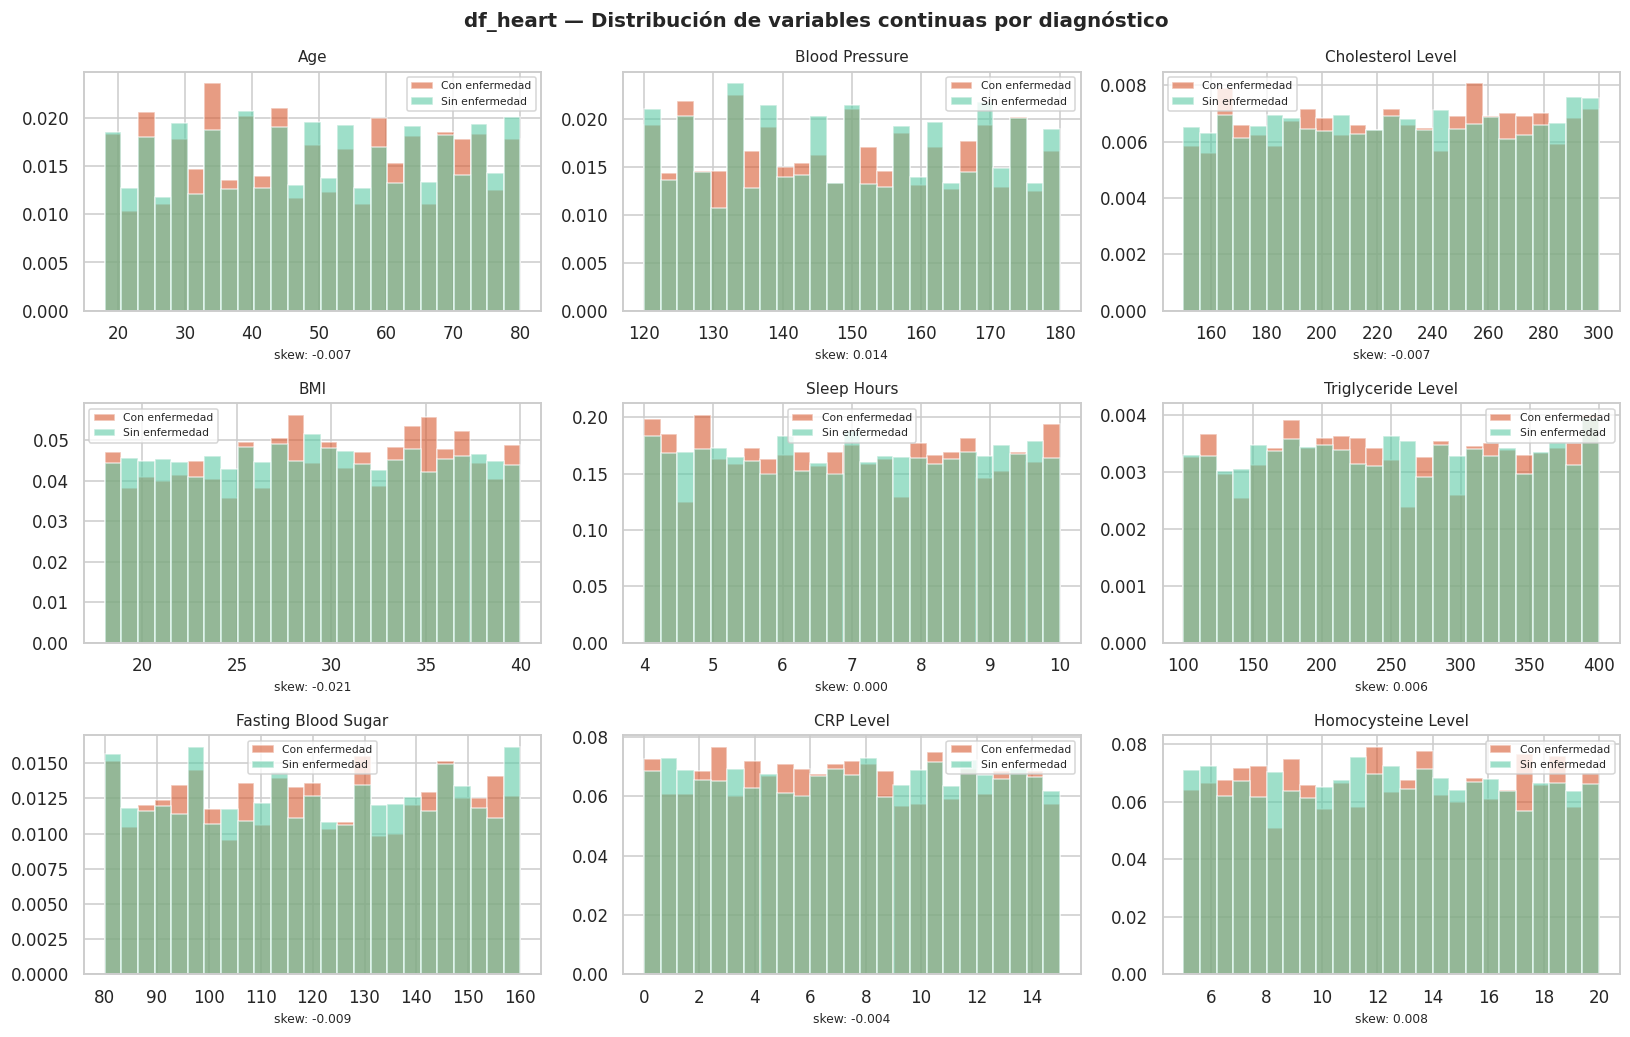

In [ ]:
cont_heart = ['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI',
              'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar',
              'CRP Level', 'Homocysteine Level']
cont_heart = [c for c in cont_heart if c in df_heart.columns]

nrows = (len(cont_heart) + 2) // 3
fig, axes = plt.subplots(nrows, 3, figsize=(15, nrows * 3.2))
axes = axes.flatten()

for i, col in enumerate(cont_heart):
    ax = axes[i]
    for val, color, lbl in [('Yes', '#D85A30', 'Con enfermedad'), ('No', '#5DCAA5', 'Sin enfermedad')]:
        subset = df_heart[df_heart['Heart Disease Status'] == val][col].dropna()
        ax.hist(subset, bins=25, alpha=0.6, color=color, label=lbl, density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)
    ax.set_xlabel(f'skew: {df_heart[col].skew():.3f}', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('df_heart — Distribución de variables continuas por diagnóstico', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4.2 Histogramas de variables continuas

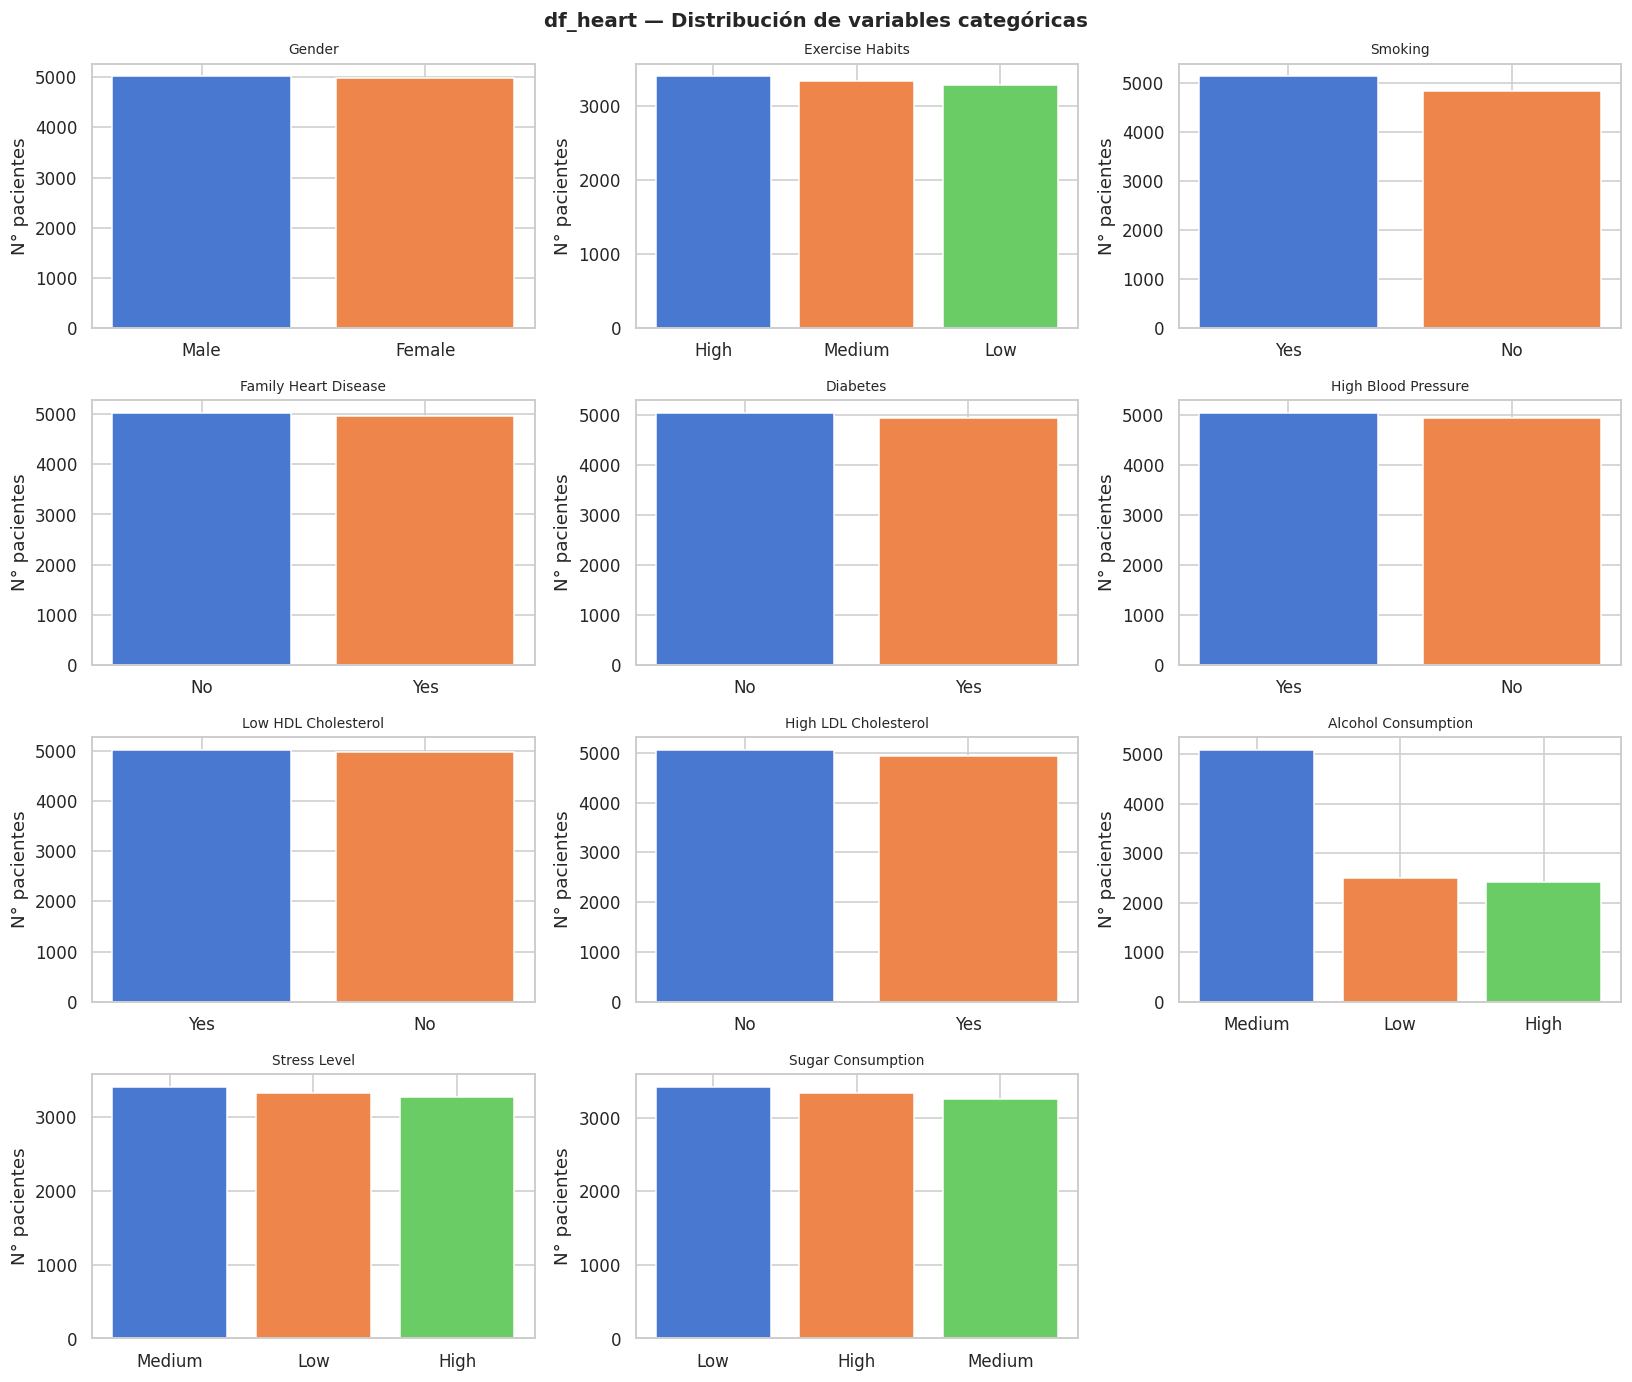

In [ ]:
# Variables categóricas
cat_heart = ['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease',
             'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol',
             'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption']
cat_heart = [c for c in cat_heart if c in df_heart.columns]

nrows = (len(cat_heart) + 2) // 3
fig, axes = plt.subplots(nrows, 3, figsize=(15, nrows * 3.2))
axes = axes.flatten()

for i, col in enumerate(cat_heart):
    ax = axes[i]
    counts = df_heart[col].value_counts()
    ax.bar(counts.index.astype(str), counts.values,
           color=sns.color_palette('muted', len(counts)), edgecolor='white')
    ax.set_title(col, fontsize=9)
    ax.set_ylabel('N° pacientes')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('df_heart — Distribución de variables categóricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4.3 Box plots por diagnóstico

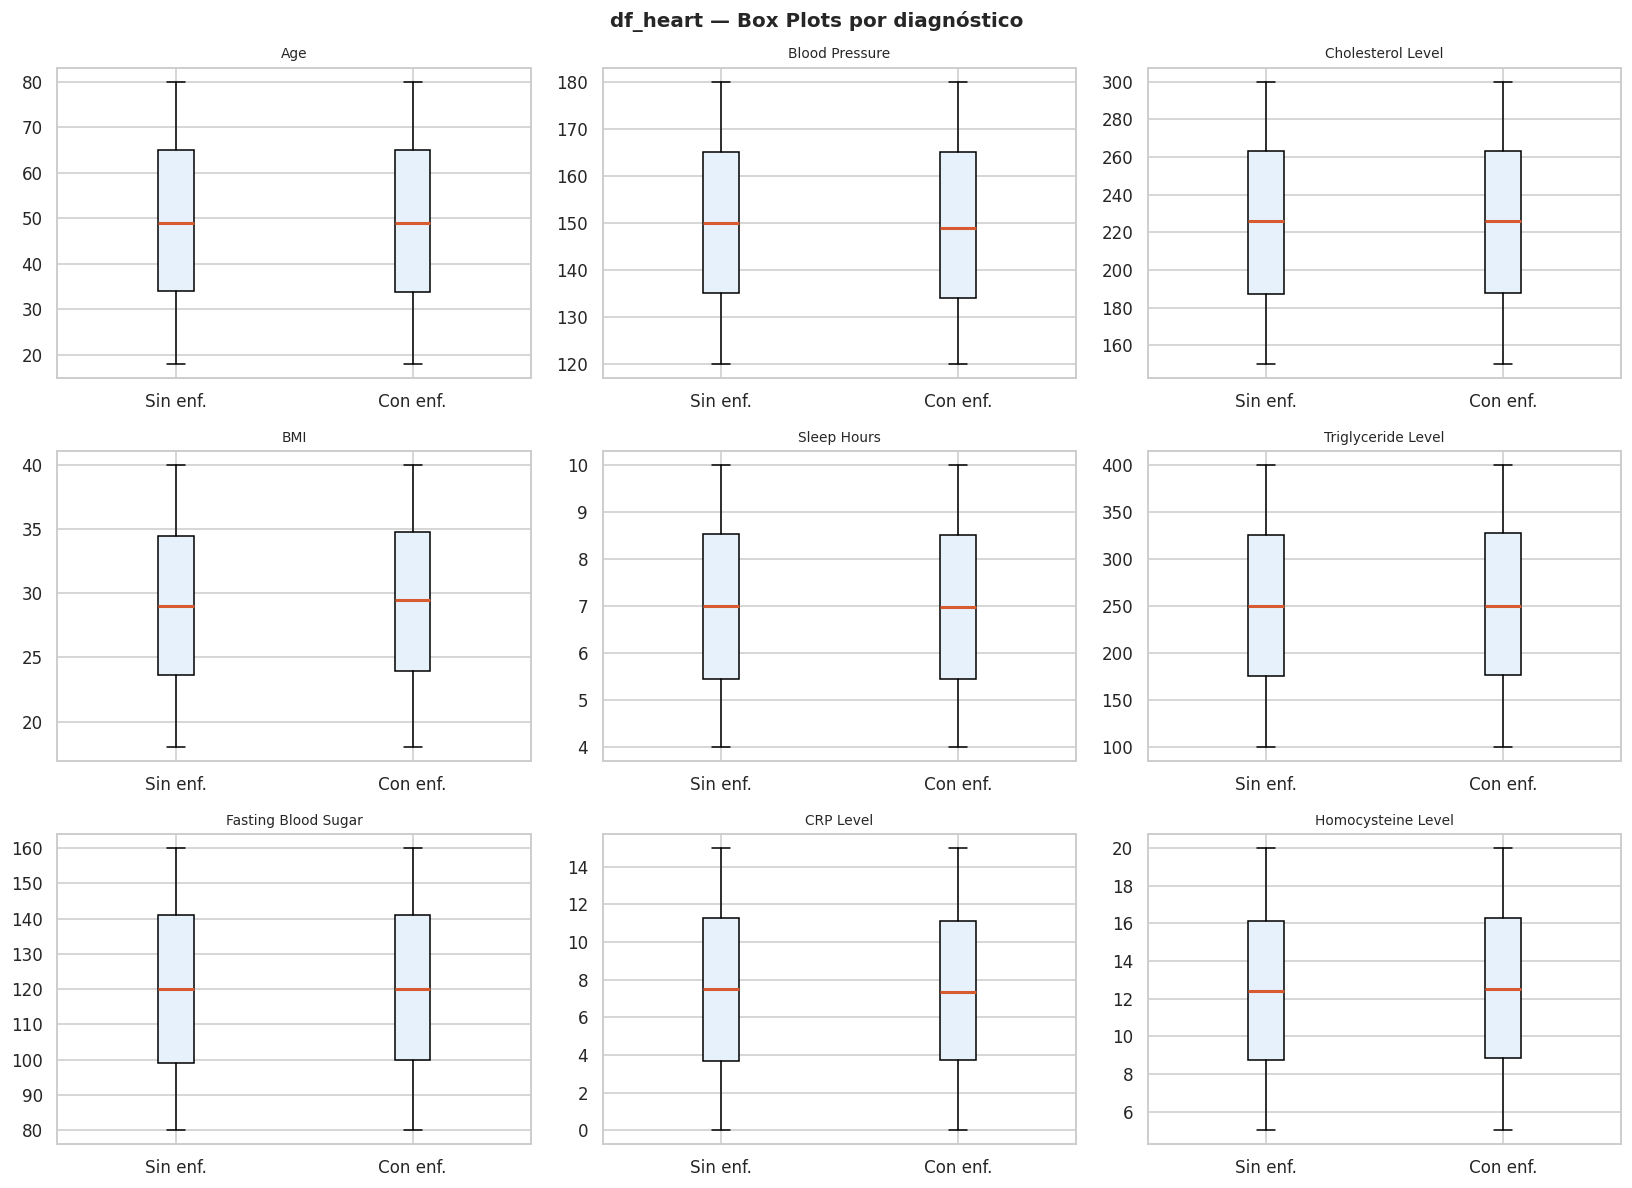


 [df_heart] Resumen de outliers (método IQR):


,Variable,Q1,Q3,IQR,N Outliers,% Outliers
0,Age,34.00,65.00,31.00,0,0.0
1,Blood Pressure,134.00,165.00,31.00,0,0.0
2,Cholesterol Level,187.00,263.00,76.00,0,0.0
3,BMI,23.67,34.51,10.84,0,0.0
4,Sleep Hours,5.46,8.53,3.07,0,0.0
5,Triglyceride Level,176.00,326.00,150.00,0,0.0
6,Fasting Blood Sugar,99.00,141.00,42.00,0,0.0
7,CRP Level,3.68,11.24,7.56,0,0.0
8,Homocysteine Level,8.73,16.13,7.40,0,0.0


,Variable,Q1,Q3,IQR,N Outliers,% Outliers
0,Age,34.00,65.00,31.00,0,0.0
1,Blood Pressure,134.00,165.00,31.00,0,0.0
2,Cholesterol Level,187.00,263.00,76.00,0,0.0
3,BMI,23.67,34.51,10.84,0,0.0
4,Sleep Hours,5.46,8.53,3.07,0,0.0
5,Triglyceride Level,176.00,326.00,150.00,0,0.0
6,Fasting Blood Sugar,99.00,141.00,42.00,0,0.0
7,CRP Level,3.68,11.24,7.56,0,0.0
8,Homocysteine Level,8.73,16.13,7.40,0,0.0


In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(cont_heart):
    ax = axes[i]
    grupos = [df_heart[df_heart['Heart Disease Status'] == v][col].dropna()
              for v in ['No', 'Yes']]
    ax.boxplot(grupos, labels=['Sin enf.', 'Con enf.'], patch_artist=True,
               boxprops=dict(facecolor='#E6F1FB'),
               medianprops=dict(color='#D85A30', linewidth=2),
               flierprops=dict(marker='.', alpha=0.3))
    ax.set_title(col, fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('df_heart — Box Plots por diagnóstico', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

resumen_outliers(df_heart, cont_heart, 'df_heart')

### 2.4.4 Mapa de calor de correlaciones

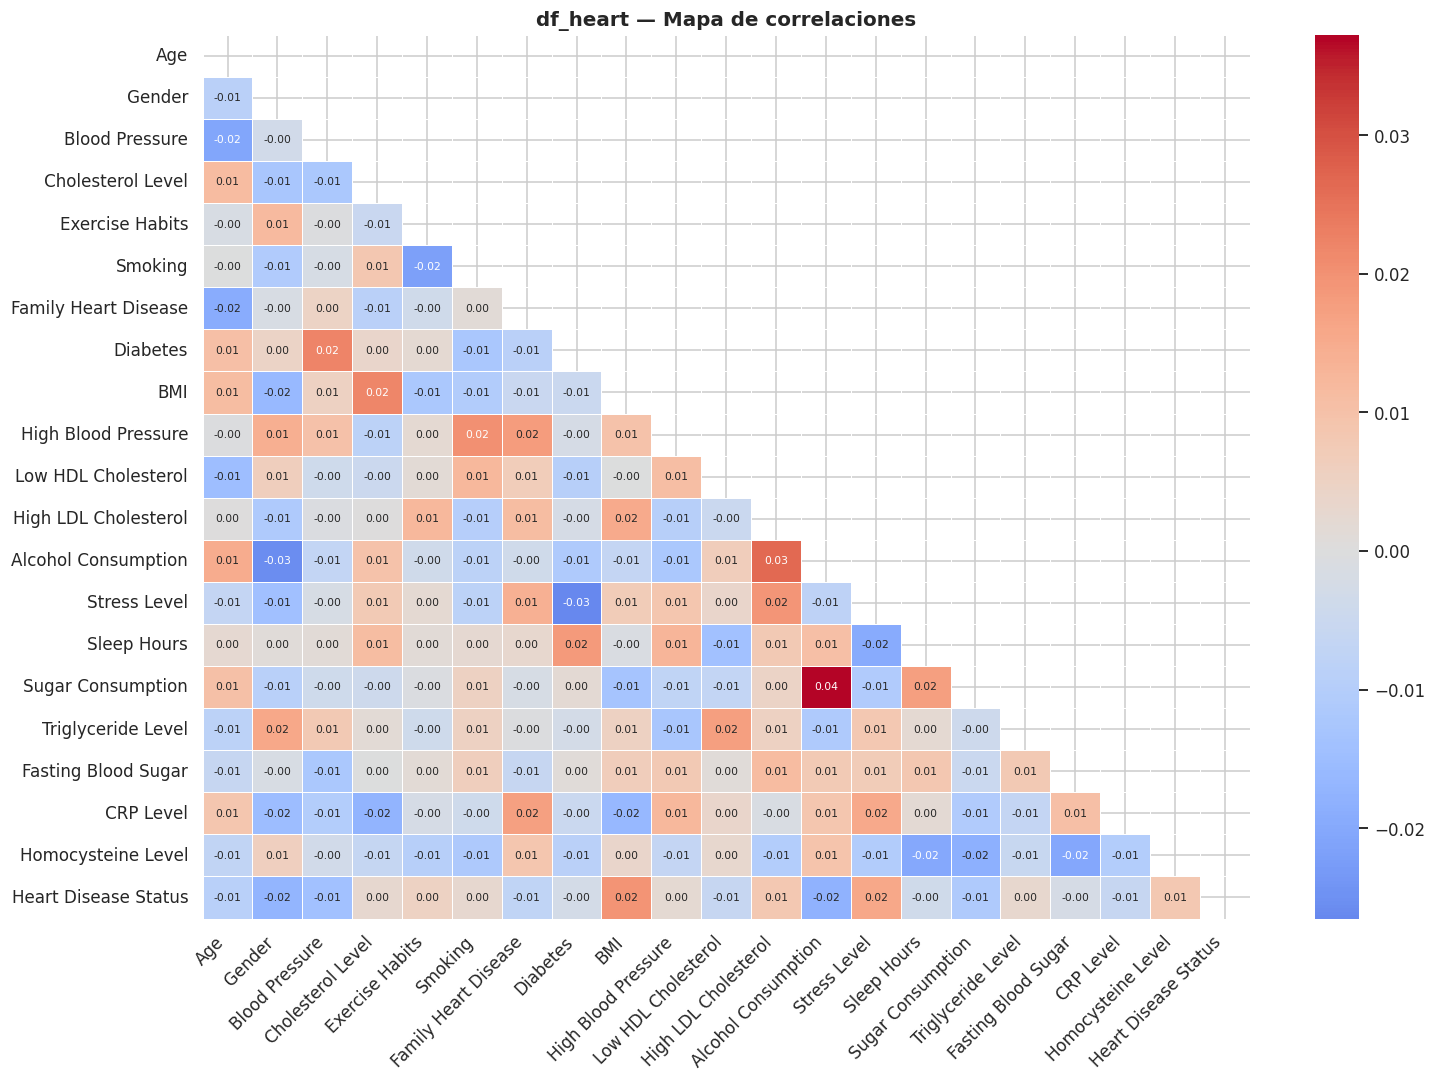


 Top correlaciones con Heart Disease Status:
BMI                      0.020
Alcohol Consumption     -0.018
Gender                  -0.017
Stress Level             0.016
Blood Pressure          -0.014
Sugar Consumption       -0.011
Age                     -0.009
Homocysteine Level       0.008
High LDL Cholesterol     0.008
Family Heart Disease    -0.008
dtype: object


In [ ]:
df_heart_enc = df_heart.copy()
for col in df_heart_enc.select_dtypes(include='object').columns:
    df_heart_enc[col] = pd.Categorical(df_heart_enc[col]).codes

corr_heart = df_heart_enc.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_heart, dtype=bool))
sns.heatmap(corr_heart, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, linecolor='white', annot_kws={'size': 7})
plt.title('df_heart — Mapa de correlaciones', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

target_enc = pd.Categorical(df_heart['Heart Disease Status']).codes
corr_target = df_heart_enc.corrwith(pd.Series(target_enc, name='Heart Disease Status'))
print('\n Top correlaciones con Heart Disease Status:')
print(corr_target.drop('Heart Disease Status', errors='ignore')
      .sort_values(key=abs, ascending=False).head(10).map(lambda x: f'{x:.3f}'))

### 2.4.5 Análisis por variable target

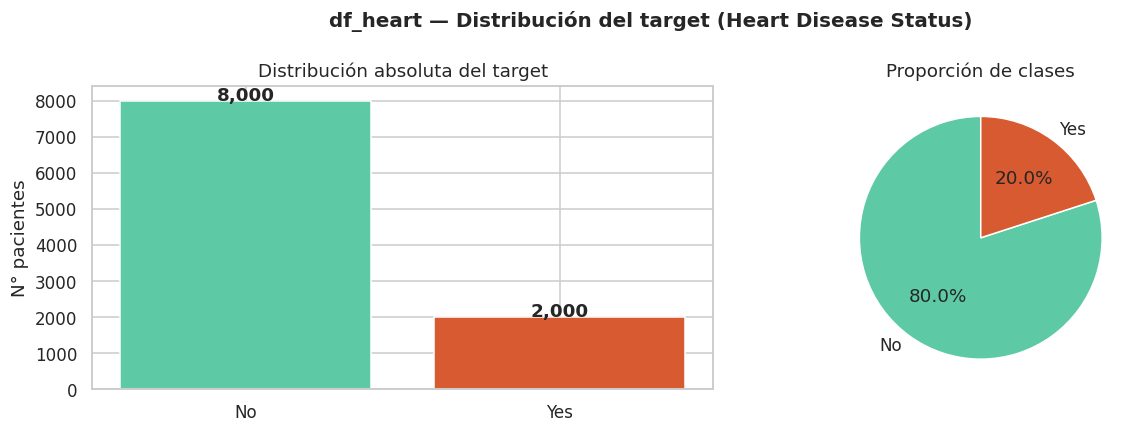

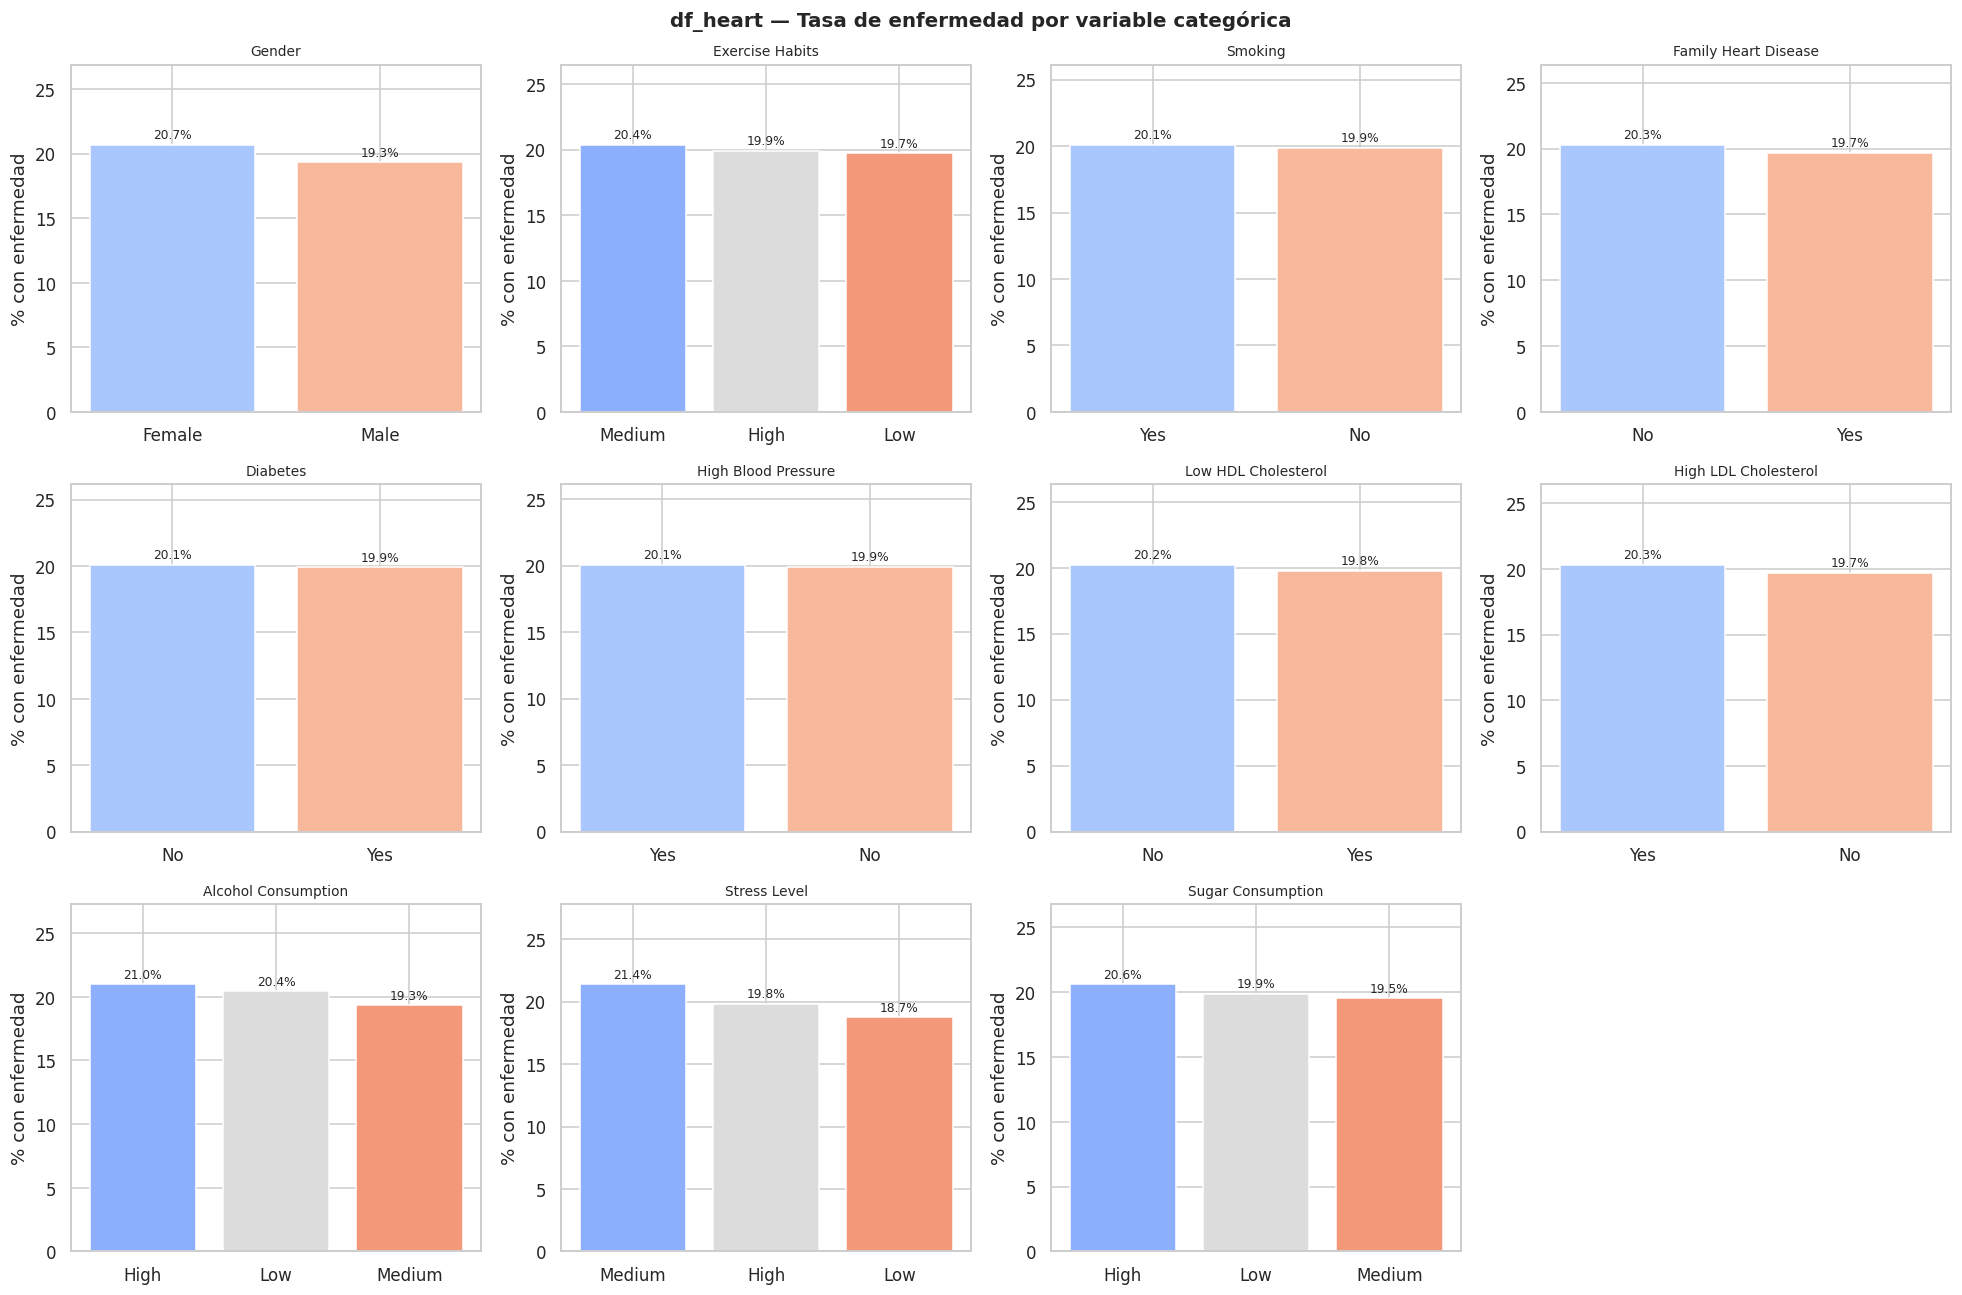

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts_heart = df_heart['Heart Disease Status'].value_counts()

axes[0].bar(counts_heart.index, counts_heart.values,
            color=['#5DCAA5', '#D85A30'], edgecolor='white')
for i, v in enumerate(counts_heart.values):
    axes[0].text(i, v + 10, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Distribución absoluta del target')
axes[0].set_ylabel('N° pacientes')

axes[1].pie(counts_heart.values, labels=counts_heart.index,
            autopct='%1.1f%%', colors=['#5DCAA5', '#D85A30'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Proporción de clases')

plt.suptitle('df_heart — Distribución del target (Heart Disease Status)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tasa de enfermedad por variable categórica
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_heart[:12]):
    ax = axes[i]
    rate = (df_heart.groupby(col)['Heart Disease Status']
            .apply(lambda x: (x == 'Yes').mean()) * 100).sort_values(ascending=False)
    bars = ax.bar(rate.index.astype(str), rate.values,
                  color=sns.color_palette('coolwarm', len(rate)), edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', fontsize=8)
    ax.set_title(col, fontsize=9)
    ax.set_ylabel('% con enfermedad')
    ax.set_ylim(0, rate.max() * 1.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('df_heart — Tasa de enfermedad por variable categórica', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.5 Resumen de hallazgos — df_heart

| Aspecto | Detalle |
|---|---|
| **Tamaño** | casi 1.000 filas × 21 columnas |
| **Nulos** | `Fasting Blood Sugar` con nulos → imputados con mediana |
| **Duplicados** | Verificados y tratados |
| **Outliers** | `CRP Level`, `Triglyceride Level` y `Homocysteine Level` con valores extremos clínicamente posibles |
| **Skewness** | `CRP Level` y `Triglyceride Level` fuertemente sesgados → transformación log recomendada |
| **Balance** | Relativamente balanceado |
| **Problemática** | **Clasificación binaria:** predecir presencia de enfermedad cardíaca |
| **Desafío** | Interpretar correctamente variables clínicas; múltiples features categóricas binarias |